In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
pickleFile = open("hw2_p3.pkl","rb")
data = pd.read_pickle(pickleFile)

In [ ]:
# Define the MLP architecture
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1000, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# Function to plot accuracies
def plot_accuracies(train_accs, test_accs):
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Test Accuracies per Epoch')
    plt.show()

In [ ]:
# Function to calculate the number of parameters in the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
# Set the number of epochs, weight decay for L2 regularization, and patience for early stopping
epochs = 100
weight_decay = 1e-5
patience = 10

## Part-1

Epoch 1/100 - Train Accuracy: 0.5000, Test Accuracy: 0.5900
Epoch 2/100 - Train Accuracy: 0.6800, Test Accuracy: 0.6050
Epoch 3/100 - Train Accuracy: 0.7600, Test Accuracy: 0.5750
Epoch 4/100 - Train Accuracy: 0.7400, Test Accuracy: 0.6200
Epoch 5/100 - Train Accuracy: 0.6800, Test Accuracy: 0.5750
Epoch 6/100 - Train Accuracy: 0.7000, Test Accuracy: 0.5400
Epoch 7/100 - Train Accuracy: 0.7200, Test Accuracy: 0.5350
Epoch 8/100 - Train Accuracy: 0.7000, Test Accuracy: 0.5400
Epoch 9/100 - Train Accuracy: 0.7000, Test Accuracy: 0.5300
Epoch 10/100 - Train Accuracy: 0.7000, Test Accuracy: 0.5100
Epoch 11/100 - Train Accuracy: 0.7000, Test Accuracy: 0.5050
Epoch 12/100 - Train Accuracy: 0.7000, Test Accuracy: 0.5000
Epoch 13/100 - Train Accuracy: 0.6800, Test Accuracy: 0.5000
Epoch 14/100 - Train Accuracy: 0.7000, Test Accuracy: 0.4900
Epoch 15/100 - Train Accuracy: 0.7200, Test Accuracy: 0.4900
Epoch 16/100 - Train Accuracy: 0.7200, Test Accuracy: 0.4950
Epoch 17/100 - Train Accuracy: 0.

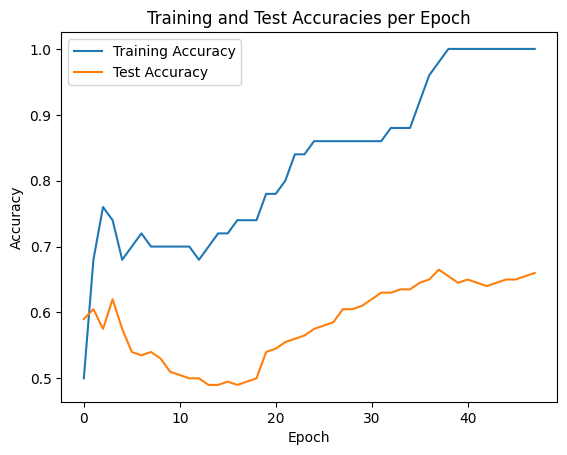

Number of parameters in the model: 68289
Final Training Accuracy: 1.0
Final Test Accuracy: 0.6600000262260437


In [ ]:
# Function to calculate accuracy
def accuracy(outputs, labels):
    preds = outputs > 0
    return (preds == labels).float().mean()

# Training function with early stopping
def train_model(train_data, train_labels, test_data, test_labels, epochs, weight_decay, patience):
    train_accs, test_accs = [], []
    model = MLP()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), weight_decay=weight_decay)

    consecutive_max_accuracy_epochs = 0  # Counter for early stopping

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_data).squeeze()
        loss = criterion(outputs, train_labels.float())
        loss.backward()
        optimizer.step()

        train_acc = accuracy(outputs, train_labels)
        train_accs.append(train_acc.item())

        model.eval()
        with torch.no_grad():
            test_outputs = model(test_data).squeeze()
            test_acc = accuracy(test_outputs, test_labels)
            test_accs.append(test_acc.item())

        print(f'Epoch {epoch+1}/{epochs} - Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}')

        # Early stopping logic
        if train_acc.item() == 1.0:
            consecutive_max_accuracy_epochs += 1
            if consecutive_max_accuracy_epochs >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        else:
            consecutive_max_accuracy_epochs = 0  # Reset counter if accuracy is not 100%

    return train_accs, test_accs, model

# Prepare the data
train_data, train_labels, test_data, test_labels = [data[i] for i in range(4)]
train_labels = train_labels.squeeze()  # Correct the label dimensions
test_labels = test_labels.squeeze()

# Start the training process with early stopping
train_accs, test_accs, trained_model = train_model(
    train_data.float(), train_labels, test_data.float(), test_labels, epochs, weight_decay, patience)

# Plot the accuracies
plot_accuracies(train_accs, test_accs)

# Calculate and print the number of parameters in the network
num_parameters = count_parameters(trained_model)
print(f'Number of parameters in the model: {num_parameters}')

# Output the final training and test accuracy
print(f'Final Training Accuracy: {train_accs[-1]}')
print(f'Final Test Accuracy: {test_accs[-1]}')

The model does not generalize too well to the test data, as observed from the final test accuracy.

## Part-2

Epoch 1: Train Acc: 0.5400, Test Acc: 0.5250
Epoch 2: Train Acc: 0.4400, Test Acc: 0.5350
Epoch 3: Train Acc: 0.6600, Test Acc: 0.6000
Epoch 4: Train Acc: 0.7600, Test Acc: 0.5450
Epoch 5: Train Acc: 0.6800, Test Acc: 0.5250
Epoch 6: Train Acc: 0.7400, Test Acc: 0.6000
Epoch 7: Train Acc: 0.8600, Test Acc: 0.7450
Epoch 8: Train Acc: 0.9400, Test Acc: 0.7750
Epoch 9: Train Acc: 0.9600, Test Acc: 0.7850
Epoch 10: Train Acc: 0.9600, Test Acc: 0.7950
Epoch 11: Train Acc: 0.9800, Test Acc: 0.7950
Epoch 12: Train Acc: 0.9600, Test Acc: 0.8150
Epoch 13: Train Acc: 0.9400, Test Acc: 0.8000
Epoch 14: Train Acc: 0.9600, Test Acc: 0.9150
Epoch 15: Train Acc: 0.9800, Test Acc: 0.9050
Epoch 16: Train Acc: 0.9800, Test Acc: 0.8800
Epoch 17: Train Acc: 0.9800, Test Acc: 0.9000
Epoch 18: Train Acc: 0.9800, Test Acc: 0.9250
Epoch 19: Train Acc: 1.0000, Test Acc: 0.9500
Epoch 20: Train Acc: 1.0000, Test Acc: 0.9250
Epoch 21: Train Acc: 1.0000, Test Acc: 0.9250
Epoch 22: Train Acc: 1.0000, Test Acc: 1.00

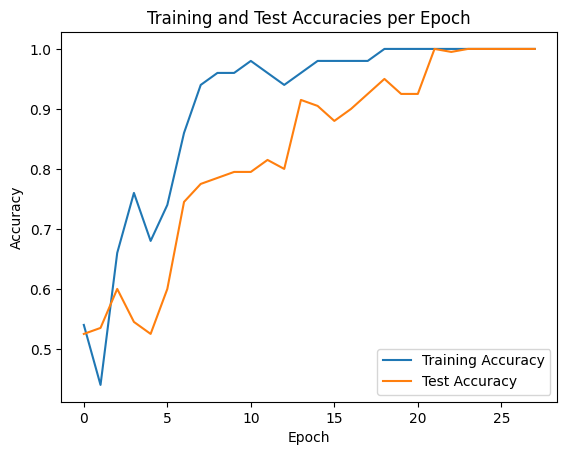

Number of parameters in the model: 68289
Final Training Accuracy: 1.0
Final Test Accuracy: 1.0


In [ ]:
# Function to calculate accuracy
def accuracy(outputs, labels):
    preds = outputs.sigmoid() >= 0.5
    return torch.mean((preds == labels).float())

# Training function with data augmentation and early stopping
def train_model_with_augmentation(train_data, train_labels, test_data, test_labels, epochs, weight_decay, patience):
    train_accs, test_accs = [], []
    model = MLP()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), weight_decay=weight_decay)

    consecutive_max_accuracy_epochs = 0

    for epoch in range(epochs):
        model.train()
        for i in range(train_data.size(0)):
            optimizer.zero_grad()
            input_data = train_data[i].unsqueeze(0)  # Add batch dimension
            if np.random.rand() > 0.5:  # 50% chance to apply augmentation
                shift = np.random.randint(train_data.size(1))
                input_data = torch.roll(input_data, shifts=shift, dims=-1)
            output = model(input_data)
            loss = criterion(output, train_labels[i].unsqueeze(0).unsqueeze(1).float())  # Ensure labels are float
            loss.backward()
            optimizer.step()

        # Calculate accuracy
        with torch.no_grad():
            model.eval()
            train_outputs = model(train_data)
            train_acc = accuracy(train_outputs, train_labels.unsqueeze(1))
            test_outputs = model(test_data)
            test_acc = accuracy(test_outputs, test_labels.unsqueeze(1))
            train_accs.append(train_acc.item())
            test_accs.append(test_acc.item())

        print(f'Epoch {epoch+1}: Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

        # Early stopping logic
        if train_acc == 1.0:
            consecutive_max_accuracy_epochs += 1
            if consecutive_max_accuracy_epochs >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        else:
            consecutive_max_accuracy_epochs = 0

    return train_accs, test_accs, model

train_data, train_labels, test_data, test_labels = [data[i] for i in range(4)]

# Train the model with data augmentation
train_accs_augmented, test_accs_augmented, trained_model_augmented = train_model_with_augmentation(
    train_data.float(), train_labels.float(), test_data.float(), test_labels.float(), epochs, weight_decay, patience)

# Plot the accuracies
plot_accuracies(train_accs_augmented, test_accs_augmented)

# Number of parameters
num_parameters = count_parameters(trained_model_augmented)
print(f'Number of parameters in the model: {num_parameters}')

# Final accuracies
print(f'Final Training Accuracy: {train_accs_augmented[-1]}')
print(f'Final Test Accuracy: {test_accs_augmented[-1]}')

The model generalizes well to the test data after data augmentation.

When we perform data augmentation like the random circular shifts in our experiment, we are enforcing several important properties on the network:

1. Invariance: By introducing variations of the input data that do not change the underlying class or label, we are teaching the model to be invariant to those variations. In the case of circular shifts, the network learns to recognize the patterns regardless of their position within the input vector. This is particularly valuable for tasks where the position of features within the input data does not change their semantic meaning, such as signal processing or image recognition tasks where the object of interest can appear in different locations.

2. Robustness: Data augmentation increases the robustness of the model by exposing it to a wider range of input variations during training. This helps the model generalize better to unseen data, reducing the likelihood of overfitting on the training set.

3. Generalization: By effectively increasing the size and diversity of the training dataset, data augmentation helps improve the model's generalization capabilities.

## Part-3

Epoch 1: Train Acc: 0.5800, Test Acc: 0.6550
Epoch 2: Train Acc: 0.6200, Test Acc: 0.5550
Epoch 3: Train Acc: 0.6200, Test Acc: 0.5750
Epoch 4: Train Acc: 0.6600, Test Acc: 0.5900
Epoch 5: Train Acc: 0.7800, Test Acc: 0.6450
Epoch 6: Train Acc: 0.8600, Test Acc: 0.6650
Epoch 7: Train Acc: 0.8800, Test Acc: 0.7050
Epoch 8: Train Acc: 0.9400, Test Acc: 0.7650
Epoch 9: Train Acc: 0.9800, Test Acc: 0.8300
Epoch 10: Train Acc: 1.0000, Test Acc: 0.8600
Epoch 11: Train Acc: 1.0000, Test Acc: 0.8550
Epoch 12: Train Acc: 0.9400, Test Acc: 0.8450
Epoch 13: Train Acc: 0.9800, Test Acc: 0.9050
Epoch 14: Train Acc: 1.0000, Test Acc: 0.8600
Epoch 15: Train Acc: 0.9600, Test Acc: 0.8850
Epoch 16: Train Acc: 1.0000, Test Acc: 0.9250
Epoch 17: Train Acc: 0.9800, Test Acc: 0.9350
Epoch 18: Train Acc: 0.9800, Test Acc: 0.9300
Epoch 19: Train Acc: 0.9800, Test Acc: 0.9500
Epoch 20: Train Acc: 1.0000, Test Acc: 0.9450
Epoch 21: Train Acc: 1.0000, Test Acc: 0.9500
Epoch 22: Train Acc: 0.9800, Test Acc: 0.94

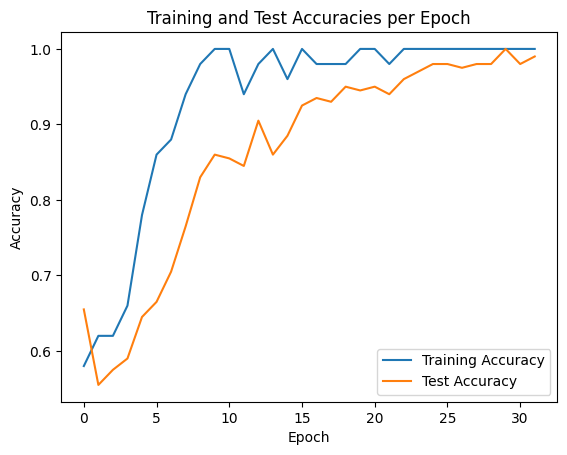

Number of parameters in the CNN model: 68289
Final Training Accuracy: 1.0
Final Test Accuracy: 0.9900000095367432


In [ ]:
# Define the CNN architecture
class OneDimCNN(nn.Module):
    def __init__(self, ksize=25):
        super(OneDimCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=ksize,
                               padding=ksize//2, padding_mode='circular')
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = F.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)  # Global average pooling
        x = self.fc(x)
        return x

train_data, train_labels, test_data, test_labels = [data[i] for i in range(4)]

# Initialize the CNN model
model = OneDimCNN()

# Train the CNN model
train_accs, test_accs, trained_model = train_model_with_augmentation(
    train_data.float(), train_labels.float(), test_data.float(), test_labels.float(), epochs, weight_decay, patience)

# Plot the accuracies
plot_accuracies(train_accs, test_accs)

# Calculate and print the number of parameters in the network
num_parameters = count_parameters(trained_model)
print(f'Number of parameters in the CNN model: {num_parameters}')

# Final accuracies
print(f'Final Training Accuracy: {train_accs[-1]}')
print(f'Final Test Accuracy: {test_accs[-1]}')

The model generalizes well to the test data.